# ТРЕНД-АНАЛИЗ

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("ТРЕНД-АНАЛИЗ КЛАСТЕРОВ")
# Загружаем данные с признаками
ml_data = pd.read_csv('data/clinical_report_clean.csv')
print(f"Загружено пациентов: {len(ml_data)}")
print(f"Доступные колонки: {ml_data.columns.tolist()[:10]}...")

# Проверяем наличие трендов
if 'sbp_trend' not in ml_data.columns:
    print("\nТренды не найдены в данных. Загружаем из исходного датасета...")
    
    # Загружаем исходный датасет с трендами
    with open('data/ts_prepared_data.pkl', 'rb') as f:
        ts_data = pickle.load(f)
    
    clustering_series = ts_data['clustering_series']
    
    # Вычисляем тренды для всех пациентов
    sbp_trends = {}
    dbp_trends = {}
    
    for patient in ml_data['patient_id'].tolist():
        if patient in clustering_series['САД']:
            sbp_series = clustering_series['САД'][patient]
            dbp_series = clustering_series['ДАД'][patient]
            
            days = np.arange(len(sbp_series))
            if len(sbp_series) >= 3:
                sbp_trends[patient] = np.polyfit(days, sbp_series, 1)[0]
                dbp_trends[patient] = np.polyfit(days, dbp_series, 1)[0]
            else:
                sbp_trends[patient] = 0
                dbp_trends[patient] = 0
        else:
            sbp_trends[patient] = 0
            dbp_trends[patient] = 0
    
    # Добавляем в датафрейм
    ml_data['sbp_trend'] = ml_data['patient_id'].map(sbp_trends)
    ml_data['dbp_trend'] = ml_data['patient_id'].map(dbp_trends)
    
    print(f"Добавлены тренды для {len(ml_data)} пациентов")

ТРЕНД-АНАЛИЗ КЛАСТЕРОВ
Загружено пациентов: 7372
Доступные колонки: ['patient_id', 'возраст', 'рост', 'масса', 'ИМТ', 'часовой пояс', 'группа наблюдения', 'САД_mean', 'САД_std', 'САД_min']...


### 1. АНАЛИЗ ТРЕНДОВ ПО КЛАСТЕРАМ

In [2]:
cluster_trends = {}

for cluster_id in [1, 2, 3]:
    print(f"\n{'='*50}")
    print(f"КЛАСТЕР {cluster_id}")
    print(f"{'='*50}")
    
    cluster_data = ml_data[ml_data['cluster'] == cluster_id]
    
    sbp_trends = cluster_data['sbp_trend'].dropna()
    dbp_trends = cluster_data['dbp_trend'].dropna()
    
    print(f"Тренд САД: средний = {sbp_trends.mean():.4f} ± {sbp_trends.std():.4f}")
    print(f"Тренд ДАД: средний = {dbp_trends.mean():.4f} ± {dbp_trends.std():.4f}")
    
    sbp_direction = "↑ повышается" if sbp_trends.mean() > 0 else "↓ снижается"
    dbp_direction = "↑ повышается" if dbp_trends.mean() > 0 else "↓ снижается"
    
    print(f"Направление: САД {sbp_direction}, ДАД {dbp_direction}")
    
    cluster_trends[cluster_id] = {
        'sbp_mean': sbp_trends.mean(),
        'sbp_std': sbp_trends.std(),
        'dbp_mean': dbp_trends.mean(),
        'dbp_std': dbp_trends.std()
    }


КЛАСТЕР 1
Тренд САД: средний = -0.0012 ± 0.0456
Тренд ДАД: средний = -0.0015 ± 0.0293
Направление: САД ↓ снижается, ДАД ↓ снижается

КЛАСТЕР 2
Тренд САД: средний = -0.0247 ± 0.2127
Тренд ДАД: средний = -0.0103 ± 0.1298
Направление: САД ↓ снижается, ДАД ↓ снижается

КЛАСТЕР 3
Тренд САД: средний = -0.0040 ± 0.0903
Тренд ДАД: средний = -0.0032 ± 0.0562
Направление: САД ↓ снижается, ДАД ↓ снижается


### 2. СТАТИСТИЧЕСКОЕ СРАВНЕНИЕ ТРЕНДОВ

In [3]:
for c1, c2 in [(1,2), (1,3), (2,3)]:
    p1 = ml_data[ml_data['cluster'] == c1]['sbp_trend'].dropna()
    p2 = ml_data[ml_data['cluster'] == c2]['sbp_trend'].dropna()
    if len(p1) > 0 and len(p2) > 0:
        t_stat, p_val = stats.ttest_ind(p1, p2)
        print(f"Кластер {c1} vs {c2}: t={t_stat:.3f}, p={p_val:.4f} {'✅ значимо' if p_val < 0.05 else '❌ не значимо'}")

Кластер 1 vs 2: t=3.129, p=0.0018 ✅ значимо
Кластер 1 vs 3: t=0.853, p=0.3937 ❌ не значимо
Кластер 2 vs 3: t=-4.503, p=0.0000 ✅ значимо


### 3. ВИЗУАЛИЗАЦИЯ

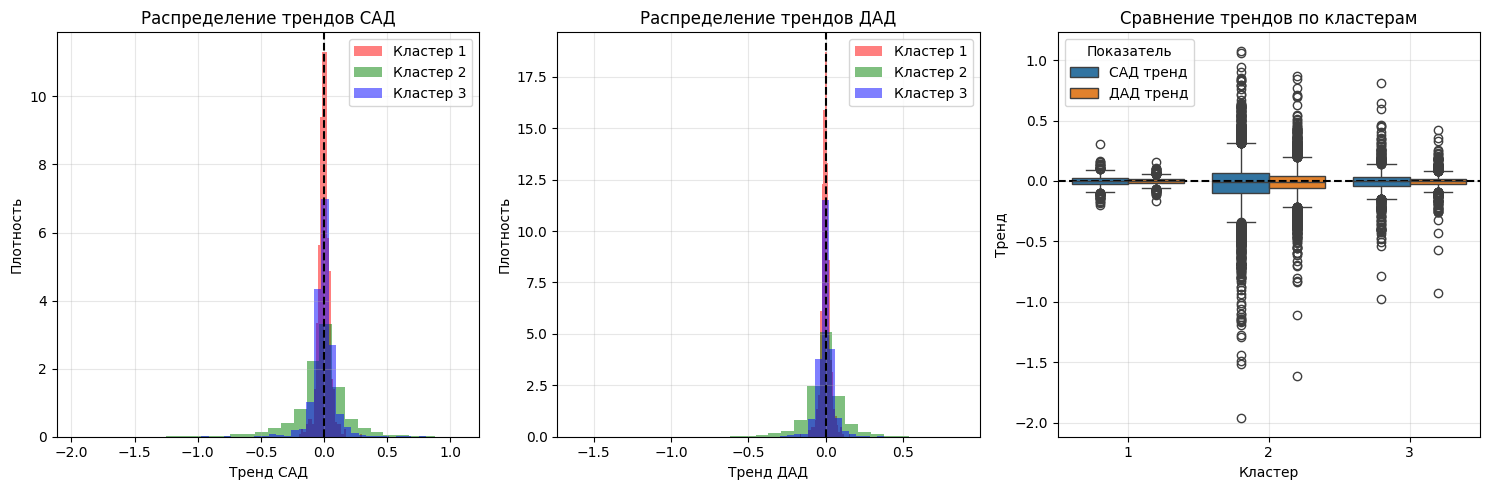

Сохранено: data/photo/trend_analysis.png

4. РЕКОМЕНДАЦИИ
 Кластер    Риск Тренд САД Вариабельность                                          Рекомендация
       1 Высокий  ↓ 0.0012         0.0456        Интенсификация терапии, ежемесячный мониторинг
       2 Средний  ↓ 0.0247         0.2127        Поддержание терапии, контроль раз в 2-3 месяца
       3  Низкий  ↓ 0.0040         0.0903 Профилактическое наблюдение, контроль раз в 6 месяцев
Сохранено: data/trend_recommendations.csv

5. КЛИНИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ

КЛАСТЕР 1:
  Положительная динамика - терапия эффективна
  Частота визитов: ежемесячно
  Цифры: САД тренд = -0.0012, ДАД тренд = -0.0015

КЛАСТЕР 2:
  Нестабильный тренд (-0.0247) - требуется контроль
  Частота визитов: раз в 2-3 месяца
  Цифры: САД тренд = -0.0247, ДАД тренд = -0.0103

КЛАСТЕР 3:
   Небольшие колебания (-0.0040) - наблюдение
  Частота визитов: раз в 6 месяцев
  Цифры: САД тренд = -0.0040, ДАД тренд = -0.0032


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['red', 'green', 'blue']
for idx, cluster_id in enumerate([1, 2, 3]):
    data = ml_data[ml_data['cluster'] == cluster_id]['sbp_trend'].dropna()
    axes[0].hist(data, bins=30, alpha=0.5, color=colors[idx], label=f'Кластер {cluster_id}', density=True)
axes[0].axvline(x=0, color='black', linestyle='--')
axes[0].set_xlabel('Тренд САД')
axes[0].set_ylabel('Плотность')
axes[0].set_title('Распределение трендов САД')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for idx, cluster_id in enumerate([1, 2, 3]):
    data = ml_data[ml_data['cluster'] == cluster_id]['dbp_trend'].dropna()
    axes[1].hist(data, bins=30, alpha=0.5, color=colors[idx], label=f'Кластер {cluster_id}', density=True)
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_xlabel('Тренд ДАД')
axes[1].set_ylabel('Плотность')
axes[1].set_title('Распределение трендов ДАД')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

trend_data = pd.DataFrame({
    'Кластер': ml_data['cluster'],
    'САД тренд': ml_data['sbp_trend'],
    'ДАД тренд': ml_data['dbp_trend']
})
trend_melted = trend_data.melt(id_vars=['Кластер'], var_name='Показатель', value_name='Тренд')
sns.boxplot(x='Кластер', y='Тренд', hue='Показатель', data=trend_melted, ax=axes[2])
axes[2].axhline(y=0, color='black', linestyle='--')
axes[2].set_title('Сравнение трендов по кластерам')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/photo/trend_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: data/photo/trend_analysis.png")

print("\n" + "="*60)
print("4. РЕКОМЕНДАЦИИ")
print("="*60)

recommendations = pd.DataFrame({
    'Кластер': [1, 2, 3],
    'Риск': ['Высокий', 'Средний', 'Низкий'],
    'Тренд САД': [
        f"{'↑' if cluster_trends[1]['sbp_mean'] > 0 else '↓'} {abs(cluster_trends[1]['sbp_mean']):.4f}",
        f"{'↑' if cluster_trends[2]['sbp_mean'] > 0 else '↓'} {abs(cluster_trends[2]['sbp_mean']):.4f}",
        f"{'↑' if cluster_trends[3]['sbp_mean'] > 0 else '↓'} {abs(cluster_trends[3]['sbp_mean']):.4f}"
    ],
    'Вариабельность': [
        f"{cluster_trends[1]['sbp_std']:.4f}",
        f"{cluster_trends[2]['sbp_std']:.4f}",
        f"{cluster_trends[3]['sbp_std']:.4f}"
    ],
    'Рекомендация': [
        'Интенсификация терапии, ежемесячный мониторинг',
        'Поддержание терапии, контроль раз в 2-3 месяца',
        'Профилактическое наблюдение, контроль раз в 6 месяцев'
    ]
})

print(recommendations.to_string(index=False))
recommendations.to_csv('data/trend_recommendations.csv', index=False)
print("Сохранено: data/trend_recommendations.csv")

print("\n" + "="*60)
print("5. КЛИНИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ")
print("="*60)

for cluster_id in [1, 2, 3]:
    print(f"\nКЛАСТЕР {cluster_id}:")
    sbp = cluster_trends[cluster_id]['sbp_mean']
    dbp = cluster_trends[cluster_id]['dbp_mean']
    
    if cluster_id == 1:
        if sbp > 0:
            print("  Прогрессирующая гипертония - требуется усиление терапии")
        else:
            print("  Положительная динамика - терапия эффективна")
        print(f"  Частота визитов: ежемесячно")
    
    elif cluster_id == 2:
        if abs(sbp) < 0.001:
            print("  Стабильное состояние - поддержание терапии")
        else:
            print(f"  Нестабильный тренд ({sbp:.4f}) - требуется контроль")
        print(f"  Частота визитов: раз в 2-3 месяца")
    
    else:
        if abs(sbp) < 0.001:
            print("   Оптимальное состояние - профилактика")
        else:
            print(f"   Небольшие колебания ({sbp:.4f}) - наблюдение")
        print(f"  Частота визитов: раз в 6 месяцев")
    
    print(f"  Цифры: САД тренд = {sbp:.4f}, ДАД тренд = {dbp:.4f}")